# 4. Avaliação orientada a jogadores

Esta camada de avaliação **qualitativa** mantém o mesmo objetivo dos artefatos anteriores: sair do ranking agregado de condições e permitir **inspeção nominal** — escolher jogadores pelo nome, comparar perfis, medir proximidade entre eles e recuperar vizinhos similares de forma reproduzível.

As perguntas continuam as mesmas:
- quais jogadores são mais próximos entre si dentro de um conjunto de features;
- como diferentes métricas alteram os vizinhos recomendados;
- quais atributos mais explicam a aproximação entre dois ou mais nomes.

**O que esta versão acrescenta — robustez, sem mudar o objetivo:**
1. **Engine canônico.** Em vez de reimplementar distâncias, reutiliza `spss.retrieval.Retriever` e `spss.distances` — as mesmas primitivas testadas do Notebook 3. Os números aqui batem exatamente com o experimento principal e com o dicionário exportado.
2. **Scores honestos.** Distância euclidiana **real** (não ao quadrado) e similaridade de cosseno/Pearson em `[-1, 1]`, idênticas ao `neighbors.csv`.
3. **À prova de homônimos.** Jogadores famosos são fixados por **UID**, nunca por nome — nomes colidem em massa (centenas de "...Son...", dezenas de "Ronaldo", e "Messi" recupera *Junior Messias* antes de Lionel Messi).
4. **Dicionário pré-computado.** Carrega o `neighbors.csv` (~836 MB, ~9,4 mi de linhas) via DataFrame de forma econômica — leitura em blocos, mantendo só as consultas de interesse.
5. **Auditoria de reprodutibilidade.** Confere que o engine ao vivo reproduz exatamente o dicionário exportado pelo Notebook 3.

In [1]:
from __future__ import annotations

import json
import sys
import time
import unicodedata
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")

# ------------------------------------------------------------------- caminhos
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "processed"
RAW_PATH = ROOT / "data" / "merged_players (1).csv"
OUTFIELD_RAW_PATH = DATA_DIR / "outfield_raw.csv"
FEATURE_SETS_PATH = DATA_DIR / "feature_sets.json"
NEIGHBORS_PATH = DATA_DIR / "neighbors.csv"
MODEL_SUMMARY_PATH = DATA_DIR / "model_selection_summary.json"

# -------------------------------------------------- engine canônico (testado)
# Reaproveitamos as primitivas validadas do Notebook 3 em vez de reimplementar
# distâncias — isso garante números idênticos ao experimento e ao dicionário.
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
from spss.distances import METRIC_LABELS, METRICS, score_block
from spss.retrieval import ASPECT_ALIASES, Retriever

with open(FEATURE_SETS_PATH, encoding="utf-8") as handle:
    feature_sets = json.load(handle)
ALL_FEATURES = [c for cols in feature_sets.values() for c in cols]

# Recuperador canônico: resolve consultas, calcula vizinhos e alinha metadados.
ret = Retriever.from_artifacts(DATA_DIR, RAW_PATH)

# Atributos brutos (escala 1-20) apenas para LER perfis e diferenças.
df_raw = pd.read_csv(OUTFIELD_RAW_PATH).drop_duplicates("UID").set_index("UID")

# Metadados de todo o universo bruto (p/ busca por nome) + marcador de linha.
player_meta = (
    pd.read_csv(RAW_PATH, usecols=["UID", "Name", "Club", "Position", "Age", "Nat"])
    .drop_duplicates("UID")
    .reset_index(drop=True)
)
player_meta["outfield"] = player_meta["UID"].isin(set(ret.uids.tolist()))
meta_by_uid = player_meta.set_index("UID")

# Default opcional do Notebook 3 (se exportado); senão, lente documentada.
if MODEL_SUMMARY_PATH.exists():
    with open(MODEL_SUMMARY_PATH, encoding="utf-8") as handle:
        model_selection_summary = json.load(handle)
    DEFAULT_ASPECT = model_selection_summary["feature_set_key"]
    DEFAULT_METRIC = model_selection_summary["metric_key"]
else:
    model_selection_summary = None
    DEFAULT_ASPECT, DEFAULT_METRIC = "technical", "euclidean"

# ------------------------------------------------------------------ sanidade
assert len(ALL_FEATURES) == 36 == len(set(ALL_FEATURES))
assert len(ret.uids) == len(set(ret.uids.tolist())), "UIDs duplicados no universo."
assert NEIGHBORS_PATH.exists(), "neighbors.csv ausente - rode o Notebook 3."

print(f"Projeto:                  {ROOT}")
print(f"Universo de linha:        {len(ret.uids):,} jogadores")
print(f"Combinacoes disponiveis:  {len(ret.aspects)} aspectos x {len(METRICS)} metricas = {len(ret.aspects) * len(METRICS)}")
print(f"Dicionario pre-computado: {NEIGHBORS_PATH.name} ({NEIGHBORS_PATH.stat().st_size / 1e6:,.0f} MB)")
print(f"Lente padrao:             aspecto={DEFAULT_ASPECT!r}, metrica={DEFAULT_METRIC!r}")

Projeto:                  /home/gupessanha/Documentos/REPOS/SPSS
Universo de linha:        78,283 jogadores
Combinacoes disponiveis:  4 aspectos x 3 metricas = 12
Dicionario pre-computado: neighbors.csv (836 MB)
Lente padrao:             aspecto='technical', metrica='euclidean'


## 1. Um elenco de jogadores famosos (fixados por UID)

Toda a análise é ancorada em craques reconhecíveis, para que os resultados sejam fáceis de *sanity-checar*. Cada jogador é fixado pelo seu **UID** — a chave única — porque resolver por nome é frágil: este dataset (Football Manager, ~2022/23) está cheio de homônimos. Curiosidade factual deste recorte: **Cristiano Ronaldo e Casemiro não constam** dele; só há "Cristiano"/"Ronaldo" brasileiros de menor expressão. Mais um motivo para nunca confiar no nome.

In [2]:
# Craques fixados POR UID (nao por nome): nomes colidem demais para confiar.
# UIDs verificados contra o dataset (FM ~2022/23).
FAMOUS = {
    "Lionel Messi": 7458500,
    "Neymar": 19024412,
    "Kylian Mbappé": 85139014,
    "Erling Haaland": 29179241,
    "Robert Lewandowski": 719601,
    "Karim Benzema": 8435089,
    "Mohamed Salah": 98028755,
    "Harry Kane": 28049320,
    "Heung-Min Son": 92020288,
    "Vinícius Júnior": 19302146,
    "Sadio Mané": 85100467,
    "Kevin De Bruyne": 18004457,
    "Luka Modrić": 653054,
    "Toni Kroos": 156772,
    "Joshua Kimmich": 92039023,
    "Pedri": 67293495,
    "Bernardo Silva": 55041632,
    "Virgil van Dijk": 37024025,
    "Rúben Dias": 55070299,
}

# Verificacao dura: todo UID precisa existir uma unica vez no universo de linha.
missing = [n for n, u in FAMOUS.items() if int(u) not in ret.uid_to_row]
assert not missing, f"UIDs fora do universo de linha: {missing}"

roster = meta_by_uid.loc[list(FAMOUS.values()), ["Name", "Club", "Age", "Position", "Nat"]].copy()
roster.insert(0, "rótulo", list(FAMOUS.keys()))
roster.insert(1, "primary_role", [ret.roles[ret.uid_to_row[u]] for u in FAMOUS.values()])
roster = roster.reset_index().rename(columns={"UID": "uid"})
print(f"Roster verificado: {len(roster)} craques, todos no universo consultavel.")
display(roster)

Roster verificado: 19 craques, todos no universo consultavel.


,uid,rótulo,primary_role,Name,Club,Age,Position,Nat
0,7458500,Lionel Messi,AM,Lionel Messi,PSG,35,"AM (RC), ST (C)",ARG
1,19024412,Neymar,MID,Neymar,PSG,30,"M (L), AM (LC), ST (C)",BRA
2,85139014,Kylian Mbappé,AM,Kylian Mbappé,PSG,23,"AM (RL), ST (C)",FRA
3,29179241,Erling Haaland,FW,Erling Haaland,Man City,21,ST (C),NOR
4,719601,Robert Lewandowski,FW,Robert Lewandowski,Barcelona,33,ST (C),POL
5,8435089,Karim Benzema,FW,Karim Benzema,R. Madrid,34,ST (C),FRA
6,98028755,Mohamed Salah,AM,Mohamed Salah,Liverpool,30,"AM (RL), ST (C)",EGY
7,28049320,Harry Kane,AM,Harry Kane,Tottenham,28,"AM (C), ST (C)",ENG
8,92020288,Heung-Min Son,MID,Heung-Min Son,Tottenham,29,"M/AM (L), ST (C)",KOR
9,19302146,Vinícius Júnior,AM,Vinícius Júnior,R. Madrid,21,AM (RL),BRA


## 2. Descoberta de nomes e a armadilha dos homônimos

Antes de montar qualquer comparação é preciso achar o **UID** certo. A busca por trecho de nome serve para *explorar*, nunca para *decidir*: um único trecho casa com centenas de jogadores. O resolvedor canônico (`Retriever.resolve_query`) trata colisão de nome como **erro explícito** — devolve a lista de candidatos para você desambiguar — em vez de adivinhar silenciosamente.

In [3]:
def _norm(text: str) -> str:
    """Casefold sem acentos - so para BUSCA exploratoria, nunca para decidir."""
    return unicodedata.normalize("NFKD", str(text)).encode("ascii", "ignore").decode().lower()

_meta_norm = player_meta["Name"].map(_norm)

def find_players(substring: str, limit: int = 12) -> pd.DataFrame:
    """Lista candidatos por trecho de nome - para voce achar o UID certo."""
    hits = player_meta[_meta_norm.str.contains(_norm(substring), na=False)]
    cols = ["UID", "Name", "Club", "Age", "Position", "Nat", "outfield"]
    return (
        hits[cols]
        .sort_values(["outfield", "Age"], ascending=[False, False])
        .head(limit)
        .reset_index(drop=True)
    )

def to_uid(query) -> int:
    """UID a partir de UID (robusto) ou nome EXATO; nome ambiguo levanta erro."""
    return int(ret.uids[ret.resolve_query(query)])

# Por que NAO resolvemos por nome: um trecho casa com muitos jogadores.
probes = ["Son", "Ronaldo", "Messi", "Cristiano Ronaldo"]
trap = pd.DataFrame({
    "trecho buscado": probes,
    "candidatos no dataset": [int(_meta_norm.str.contains(_norm(p), na=False).sum()) for p in probes],
})
print("Quantos jogadores casam com cada trecho (e por isso fixamos UID):")
display(trap)

print("Buscar 'Son' por substring e ruidoso:")
display(find_players("Son", limit=5))

_row = ret.meta.iloc[ret.resolve_query(92020288)]
print(f"...mas o UID 92020288 resolve para UMA linha: {_row['Name']} ({_row['Club']}, {_row['primary_role']})\n")

try:
    _idx = ret.resolve_query("Ronaldo")
    print("resolve('Ronaldo') resolveu para:", ret.meta.iloc[_idx]["Name"])
except ValueError as exc:
    print("resolve('Ronaldo') recusa adivinhar (mostra candidatos):")
    print("  " + str(exc).split(chr(10))[0])

Quantos jogadores casam com cada trecho (e por isso fixamos UID):


,trecho buscado,candidatos no dataset
0,Son,2692
1,Ronaldo,55
2,Messi,18
3,Cristiano Ronaldo,0


Buscar 'Son' por substring e ruidoso:


,UID,Name,Club,Age,Position,Nat,outfield
0,2000015275,Chad Johnson,Boca Raton FC,43,ST (C),USA,True
1,1403409,Emerson,Olbia,41,"D (C), DM",BRA,True
2,127378,Ode Thompson,Daring Maria-Aalter,41,ST (C),NGA,True
3,2102883,Anderson Andrade,NaN,40,ST (C),BRA,True
4,19040965,Thompson,Luziânia,40,"D/WB (R), DM",BRA,True


...mas o UID 92020288 resolve para UMA linha: Heung-Min Son (Tottenham, MID)

resolve('Ronaldo') recusa adivinhar (mostra candidatos):
  8 jogadores chamados 'Ronaldo'. Especifique por UID:


## 3. O dicionário pré-computado de vizinhos (`neighbors.csv`)

O Notebook 3 exportou, para **todos** os 78.283 jogadores de linha, os top-10 vizinhos em cada aspecto (T/M/F/SP) × métrica (Euclidiana/Cosseno/Pearson) — cerca de **9,4 milhões de linhas, ~836 MB**. Carregá-lo inteiro custa minutos e vários GB de RAM (foi o que o Notebook 5 fez de forma ingênua). Aqui lemos **em blocos** e ficamos só com as consultas do nosso elenco, resultando num DataFrame compacto que serve de cache instantâneo para o resto da análise — exatamente o "carregar via DataFrame por ser um dicionário muito grande".

In [4]:
NEIGHBORS_DTYPES = {
    "query_uid": "int64", "query_name": "string", "query_role": "category",
    "aspect": "category", "metric": "category", "rank": "int16",
    "neighbor_uid": "int64", "neighbor_name": "string", "neighbor_role": "category",
    "score": "float32", "score_kind": "category",
}

def load_precomputed_neighbors(uids, path=NEIGHBORS_PATH, chunksize=1_000_000, verbose=True):
    """Carrega so as linhas do dicionario cujas CONSULTAS estao em `uids`.

    O arquivo tem ~9,4 mi de linhas (~836 MB); le-lo inteiro custa minutos e
    varios GB. Percorremos em blocos e mantemos apenas as consultas desejadas -
    uma unica passada, memoria plana, resultado compacto.
    """
    wanted = {int(u) for u in uids}
    start = time.time()
    scanned, kept = 0, []
    for chunk in pd.read_csv(path, chunksize=chunksize, dtype=NEIGHBORS_DTYPES):
        scanned += len(chunk)
        kept.append(chunk[chunk["query_uid"].isin(wanted)])
    out = pd.concat(kept, ignore_index=True)
    if verbose:
        print(f"Varridas {scanned:,} linhas em {time.time() - start:,.1f}s; "
              f"mantidas {len(out):,} ({out['query_uid'].nunique()} consultas).")
    return out

roster_neighbors = load_precomputed_neighbors(FAMOUS.values())

def precomputed_neighbors(query, aspect="technical", metric="euclidean", k=10, frame=None):
    """Top-k vizinhos de `query` direto do dicionario pre-computado (instantaneo)."""
    frame = roster_neighbors if frame is None else frame
    alias = ASPECT_ALIASES[ret._resolve_aspect(aspect)]
    sel = frame[(frame["query_uid"] == to_uid(query))
                & (frame["aspect"] == alias)
                & (frame["metric"] == METRIC_LABELS[metric])
                & (frame["rank"] <= k)]
    cols = ["rank", "neighbor_uid", "neighbor_name", "neighbor_role", "score", "score_kind"]
    return sel.sort_values("rank")[cols].reset_index(drop=True)

print(f"Cache compacto: {roster_neighbors.shape[0]:,} linhas, "
      f"{roster_neighbors.memory_usage(deep=True).sum() / 1e6:,.1f} MB (vs ~836 MB do arquivo).")
display(roster_neighbors.head(6))

Varridas 9,393,960 linhas em 31.6s; mantidas 2,280 (19 consultas).
Cache compacto: 2,280 linhas, 0.7 MB (vs ~836 MB do arquivo).


,query_uid,query_name,query_role,aspect,metric,rank,neighbor_uid,neighbor_name,neighbor_role,score,score_kind
0,19302146,Vinícius Júnior,AM,T,Euclidiana,1,13136629,Taiwo Awoniyi,FW,1.526628,distance
1,19302146,Vinícius Júnior,AM,T,Euclidiana,2,29125842,Jarrod Bowen,MID,1.575826,distance
2,19302146,Vinícius Júnior,AM,T,Euclidiana,3,67276122,Ansu Fati,AM,1.783661,distance
3,19302146,Vinícius Júnior,AM,T,Euclidiana,4,62042273,Aleksandar Katai,AM,1.789887,distance
4,19302146,Vinícius Júnior,AM,T,Euclidiana,5,76020280,Johan Mojica,DEF,1.793297,distance
5,19302146,Vinícius Júnior,AM,T,Euclidiana,6,43426047,Destiny Udogie,DEF,1.827454,distance


## 4. Auditoria de reprodutibilidade (engine ao vivo × dicionário)

Robustez de verdade significa que a recuperação **ao vivo** (calculada agora pelo `Retriever`) e o **dicionário** exportado pelo Notebook 3 concordam. Para cada craque, em cada aspecto × métrica, comparamos os top-10 por UID (Jaccard) e o desvio máximo de score honesto. A expectativa é Jaccard ≈ 1,0 e Δscore ≈ 0 — se isso valer, o dicionário é um atalho confiável para o engine.

In [5]:
def _jaccard(a, b):
    sa, sb = set(map(int, a)), set(map(int, b))
    return len(sa & sb) / len(sa | sb) if (sa | sb) else 1.0

K = 10
rows = []
for uid in FAMOUS.values():
    for aspect in ret.aspects:
        for metric in METRICS:
            live = ret.similar(uid, aspect=aspect, metric=metric, k=K)
            pre = precomputed_neighbors(uid, aspect=aspect, metric=metric, k=K)
            score_col = "distance" if metric == "euclidean" else "similarity"
            merged = live.merge(pre, left_on="UID", right_on="neighbor_uid", how="inner")
            delta = float((merged[score_col] - merged["score"]).abs().max()) if len(merged) else float("nan")
            rows.append({
                "aspecto": ASPECT_ALIASES[aspect],
                "métrica": METRIC_LABELS[metric],
                "jaccard@10": _jaccard(live["UID"], pre["neighbor_uid"]),
                "max_delta_score": delta,
            })

audit = pd.DataFrame(rows)
summary = (
    audit.groupby(["aspecto", "métrica"], observed=True)
    .agg(jaccard_medio=("jaccard@10", "mean"),
         pior_jaccard=("jaccard@10", "min"),
         pior_delta=("max_delta_score", "max"))
    .reset_index()
)
display(summary)
worst_jaccard = float(audit["jaccard@10"].min())
worst_delta = float(np.nanmax(audit["max_delta_score"]))
print(f"Concordancia engine<->dicionario | Jaccard@10 medio={audit['jaccard@10'].mean():.4f}, "
      f"pior (por condicao)={worst_jaccard:.4f}, maior delta de score={worst_delta:.2e}")
# Checagem GRANULAR: nenhuma condicao isolada pode divergir - a media esconderia
# um outlier (ex.: uma unica metrica quebrada cairia para ~0 sem mexer na media).
assert worst_jaccard >= 0.95, f"Condicao divergente: pior Jaccard@10={worst_jaccard:.3f}."
assert worst_delta < 1e-3, f"Score desalinhado engine<->dicionario: delta={worst_delta:.2e}."

,aspecto,métrica,jaccard_medio,pior_jaccard,pior_delta
0,F,Cosseno,1.0,1.0,0.0
1,F,Euclidiana,1.0,1.0,0.0
2,F,Pearson,1.0,1.0,0.0
3,M,Cosseno,1.0,1.0,0.0
4,M,Euclidiana,1.0,1.0,0.0
5,M,Pearson,1.0,1.0,0.0
6,SP,Cosseno,1.0,1.0,0.0
7,SP,Euclidiana,1.0,1.0,0.0
8,SP,Pearson,1.0,1.0,0.0
9,T,Cosseno,1.0,1.0,0.0


Concordancia engine<->dicionario | Jaccard@10 medio=1.0000, pior (por condicao)=1.0000, maior delta de score=0.00e+00


## 5. Comparação nominal par a par

Objetivo original preservado: dada uma lista de nomes, medir a proximidade **par a par** dentro de um aspecto × métrica e *ler* essa proximidade em termos de atributos brutos. Aqui comparamos um grupo de atacantes de elite. Edite `COMPARE` (sempre por UID) e os parâmetros `ASPECT`/`METRIC` à vontade. A matriz usa scores honestos: distância euclidiana real, ou similaridade de cosseno/Pearson.

,Lionel Messi,Kylian Mbappé,Erling Haaland,Robert Lewandowski,Karim Benzema,Mohamed Salah
Lionel Messi,1.000,0.953,0.918,0.848,0.942,0.959
Kylian Mbappé,0.953,1.000,0.858,0.799,0.853,0.927
Erling Haaland,0.918,0.858,1.000,0.969,0.935,0.966
Robert Lewandowski,0.848,0.799,0.969,1.000,0.909,0.921
Karim Benzema,0.942,0.853,0.935,0.909,1.000,0.957
Mohamed Salah,0.959,0.927,0.966,0.921,0.957,1.000


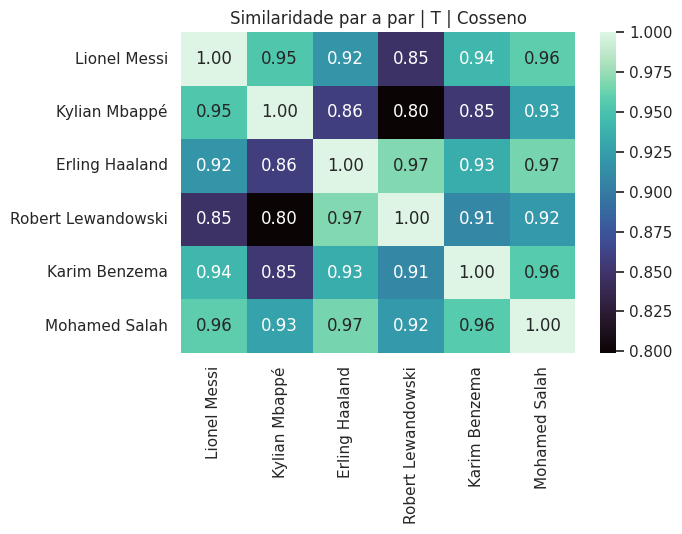

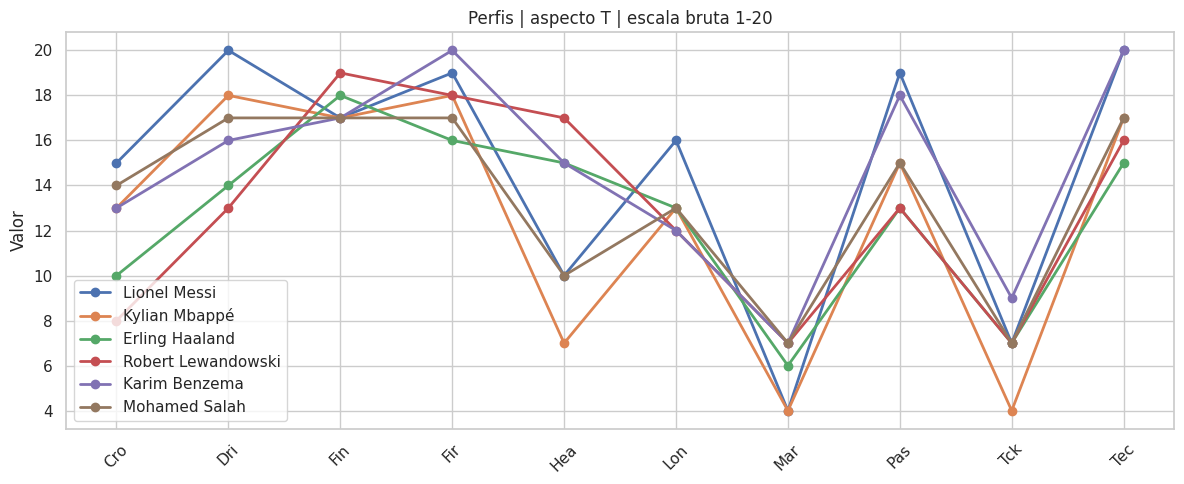

,Cro,Dri,Fin,Fir,Hea,Lon,Mar,Pas,Tck,Tec
Lionel Messi,15,20,17,19,10,16,4,19,7,20
Kylian Mbappé,13,18,17,18,7,13,4,15,4,17
Erling Haaland,10,14,18,16,15,13,6,13,7,15
Robert Lewandowski,8,13,19,18,17,12,7,13,7,16
Karim Benzema,13,16,17,20,15,12,7,18,9,20
Mohamed Salah,14,17,17,17,10,13,7,15,7,17


In [6]:
def pairwise(uids, aspect=DEFAULT_ASPECT, metric=DEFAULT_METRIC, labels=None):
    """Matriz de proximidade HONESTA entre os jogadores escolhidos.

    Usa o mesmo espaco metrico preparado da recuperacao. Devolve distancia
    euclidiana real (menor=mais perto) ou similaridade cosseno/Pearson em
    [-1, 1] (maior=mais perto), conforme a metrica.
    """
    aspect = ret._resolve_aspect(aspect)
    rows = [ret.uid_to_row[to_uid(u)] for u in uids]
    sub = score_block(ret.matrices[aspect][rows], ret.spaces[(aspect, metric)])[:, rows]
    if metric == "euclidean":
        mat, kind = np.sqrt(np.maximum(sub, 0.0)), "distância"
        np.fill_diagonal(mat, 0.0)
    else:
        mat, kind = 1.0 - sub, "similaridade"
        np.fill_diagonal(mat, 1.0)
    names = labels if labels is not None else [ret.meta.iloc[r]["Name"] for r in rows]
    return pd.DataFrame(mat, index=names, columns=names), kind

# Edite a vontade - sempre por UID (a prova de homonimos).
COMPARE = {k: FAMOUS[k] for k in [
    "Lionel Messi", "Kylian Mbappé", "Erling Haaland",
    "Robert Lewandowski", "Karim Benzema", "Mohamed Salah",
]}
ASPECT, METRIC = "technical", "cosine"

prox, kind = pairwise(COMPARE.values(), aspect=ASPECT, metric=METRIC, labels=list(COMPARE))
display(prox.round(3))

plt.figure(figsize=(7, 5.5))
sns.heatmap(prox, annot=True, fmt=".2f", cmap="mako" if kind == "similaridade" else "mako_r")
plt.title(f"{kind.capitalize()} par a par | {ASPECT_ALIASES[ret._resolve_aspect(ASPECT)]} | {METRIC_LABELS[METRIC]}")
plt.tight_layout(); plt.show()

# Perfis brutos (1-20) para LER a proximidade em termos de atributos.
cols = feature_sets[ret._resolve_aspect(ASPECT)]
profiles = df_raw.loc[[to_uid(u) for u in COMPARE.values()], cols].copy()
profiles.index = list(COMPARE)
plt.figure(figsize=(12, 5))
for name in profiles.index:
    plt.plot(cols, profiles.loc[name], marker="o", linewidth=2, label=name)
plt.title(f"Perfis | aspecto {ASPECT_ALIASES[ret._resolve_aspect(ASPECT)]} | escala bruta 1-20")
plt.xticks(rotation=45); plt.ylabel("Valor"); plt.legend(loc="best"); plt.tight_layout(); plt.show()
display(profiles)

## 6. Vizinhos similares por jogador

Para cada craque-consulta, recuperamos os vizinhos mais próximos direto do dicionário (instantâneo — e já auditado como idêntico ao engine ao vivo). Como a normalização z é **por posição**, vizinhos de outras posições podem aparecer: isso é esperado e remove o sinal posicional por construção (ver Avaliação A do Notebook 3).

In [7]:
QUERIES = ["Kevin De Bruyne", "Luka Modrić", "Virgil van Dijk", "Erling Haaland"]
ASPECT_N, METRIC_N = "technical", "cosine"
TOP_K = 8

for label in QUERIES:
    uid = FAMOUS[label]
    q = ret.meta.iloc[ret.uid_to_row[uid]]
    print(f"\n# {label} - {q['Club']}, {q['Position']}, {q['primary_role']} (UID {uid})")
    nb = precomputed_neighbors(uid, aspect=ASPECT_N, metric=METRIC_N, k=TOP_K).copy()
    nb.insert(2, "club", meta_by_uid.loc[nb["neighbor_uid"].astype(int), "Club"].to_numpy())
    display(nb)


# Kevin De Bruyne - Man City, M (RLC), AM (C), MID (UID 18004457)


,rank,neighbor_uid,club,neighbor_name,neighbor_role,score,score_kind
0,1,958134,Alte. Brown,José Luis García,MID,0.984425,similarity
1,2,14207446,Dep. Laferrere,Agustín Vallejos,DEF,0.981660,similarity
2,3,78011437,Perth Glory,Bruno Fornaroli,FW,0.980762,similarity
3,4,55070307,Wolves,Rúben Neves,DM,0.980432,similarity
4,5,29000484,Cartagena,Sergio Tejera,DM,0.978823,similarity
5,6,14021900,Udinese,Roberto Pereyra,WB,0.977766,similarity
6,7,79024135,CSKA Moscow,Jesús Medina,AM,0.977516,similarity
7,8,28016318,Celtic,Aaron Mooy,DM,0.975759,similarity



# Luka Modrić - R. Madrid, M/AM (C), MID (UID 653054)


,rank,neighbor_uid,club,neighbor_name,neighbor_role,score,score_kind
0,1,67174733,Santa Clara,Xavi Quintillà,DEF,0.980095,similarity
1,2,67022040,Liverpool,Thiago,DM,0.977650,similarity
2,3,954463,Estudiantes (RC),Fernando Belluschi,MID,0.971944,similarity
3,4,67142545,Villarreal,Manu Trigueros,MID,0.971449,similarity
4,5,50056317,Wil,Sofian Bahloul,AM,0.968949,similarity
5,6,42024353,Hoffenheim,Munas Dabbur,FW,0.968822,similarity
6,7,67086280,Leeds,Rodrigo,AM,0.968728,similarity
7,8,7458280,Real San Sebastián,David Silva,MID,0.968429,similarity



# Virgil van Dijk - Liverpool, D (C), DEF (UID 37024025)


,rank,neighbor_uid,club,neighbor_name,neighbor_role,score,score_kind
0,1,24026266,Rijeka,Matej Mitrović,DEF,0.988531,similarity
1,2,91012809,Nürnberg,Christopher Schindler,DEF,0.988369,similarity
2,3,12007662,Aris,Nicolas Nkoulou,DEF,0.983836,similarity
3,4,67217522,Villarreal,Pau Torres,DEF,0.983272,similarity
4,5,14000745,NaN,Mateo Musacchio,DEF,0.983180,similarity
5,6,316742,OGC Nice,Dante,DEF,0.980889,similarity
6,7,92025938,Benfica,John Brooks,DEF,0.979694,similarity
7,8,29055569,Everton,James Tarkowski,DEF,0.979139,similarity



# Erling Haaland - Man City, ST (C), FW (UID 29179241)


,rank,neighbor_uid,club,neighbor_name,neighbor_role,score,score_kind
0,1,34008670,LOSC,Rémy Cabella,MID,0.985562,similarity
1,2,91105029,VfL Wolfsburg,Yannick Gerhardt,DEF,0.984000,similarity
2,3,7987827,Toronto FC,Domenico Criscito,DEF,0.982752,similarity
3,4,67080310,Barcelona,Marcos Alonso,DEF,0.980796,similarity
4,5,67216396,PSG,Fabián,DM,0.979241,similarity
5,6,59006269,Inter,Henrikh Mkhitaryan,MID,0.978816,similarity
6,7,80028885,RSC Anderlecht,Amir Murillo,DEF,0.978732,similarity
7,8,37041773,Inter,Robin Gosens,DEF,0.977069,similarity


## 7. Sensibilidade à métrica e o que separa dois nomes

Quando os vizinhos mudam pouco entre Euclidiana, Cosseno e Pearson, a leitura qualitativa é mais robusta; quando muda muito, o perfil depende fortemente da noção de similaridade escolhida. Também inspecionamos quais **atributos brutos** mais separam dois jogadores — a ponte entre a distância numérica e a interpretação futebolística.

In [8]:
ANCHOR = "Luka Modrić"
ASPECT_S = "technical"

panels = []
for metric in METRICS:
    p = precomputed_neighbors(ANCHOR, aspect=ASPECT_S, metric=metric, k=5)
    panels.append(p["neighbor_name"].rename(METRIC_LABELS[metric]).reset_index(drop=True))
side = pd.concat(panels, axis=1)
side.index = [f"#{i}" for i in range(1, len(side) + 1)]
print(f"Top-5 de {ANCHOR} no aspecto {ASPECT_ALIASES[ret._resolve_aspect(ASPECT_S)]} - sensibilidade a metrica:")
display(side)

sets = {m: set(precomputed_neighbors(ANCHOR, aspect=ASPECT_S, metric=m, k=10)["neighbor_uid"].astype(int))
        for m in METRICS}
overlap = [{"comparação": f"{METRIC_LABELS[a]} vs {METRIC_LABELS[b]}",
            "jaccard@10": len(sets[a] & sets[b]) / len(sets[a] | sets[b])}
           for a, b in combinations(METRICS, 2)]
display(pd.DataFrame(overlap))

def pair_differences(query_a, query_b, aspect="technical", top_n=8):
    """Atributos brutos que mais SEPARAM dois jogadores (interpreta a distancia)."""
    cols = feature_sets[ret._resolve_aspect(aspect)]
    ua, ub = to_uid(query_a), to_uid(query_b)
    a, b = df_raw.loc[ua, cols], df_raw.loc[ub, cols]
    diff = (a - b).abs().sort_values(ascending=False).head(top_n)
    name_a = ret.meta.iloc[ret.uid_to_row[ua]]["Name"]
    name_b = ret.meta.iloc[ret.uid_to_row[ub]]["Name"]
    return pd.DataFrame({"attribute": diff.index,
                         name_a: a[diff.index].to_numpy(),
                         name_b: b[diff.index].to_numpy(),
                         "abs_diff": diff.to_numpy()})

print("\nAtributos que mais separam Lionel Messi de Erling Haaland (tecnico):")
display(pair_differences(FAMOUS["Lionel Messi"], FAMOUS["Erling Haaland"], aspect="technical"))

Top-5 de Luka Modrić no aspecto T - sensibilidade a metrica:


,Euclidiana,Cosseno,Pearson
#1,Thiago,Xavi Quintillà,Iván Luquet
#2,David Silva,Thiago,Bruno Sambo
#3,Mesut Özil,Fernando Belluschi,Mesut Özil
#4,Trent Alexander-Arnold,Manu Trigueros,Lucas Mendoza
#5,Marco Verratti,Sofian Bahloul,Lucio Gonzaga


,comparação,jaccard@10
0,Euclidiana vs Cosseno,0.111111
1,Euclidiana vs Pearson,0.111111
2,Cosseno vs Pearson,0.111111



Atributos que mais separam Lionel Messi de Erling Haaland (tecnico):


,attribute,Lionel Messi,Erling Haaland,abs_diff
0,Dri,20,14,6
1,Pas,19,13,6
2,Cro,15,10,5
3,Hea,10,15,5
4,Tec,20,15,5
5,Fir,19,16,3
6,Lon,16,13,3
7,Mar,4,6,2


## 8. "Gêmeos famosos": o craque mais parecido dentro do elenco

Fechando o ciclo da comparação par a par: restringindo os candidatos ao próprio elenco famoso, qual é o jogador **mais parecido** com cada um? É um *sanity-check* final — perfis parecidos devem se atrair, e os pares fazem sentido futebolístico.

,jogador,gêmeo famoso mais próximo,similaridade
0,Neymar,Kylian Mbappé,0.972858
1,Kylian Mbappé,Neymar,0.972858
2,Joshua Kimmich,Kevin De Bruyne,0.972052
3,Kevin De Bruyne,Joshua Kimmich,0.972052
4,Lionel Messi,Neymar,0.971774
5,Erling Haaland,Robert Lewandowski,0.969146
6,Robert Lewandowski,Erling Haaland,0.969146
7,Luka Modrić,Pedri,0.966642
8,Pedri,Luka Modrić,0.966642
9,Mohamed Salah,Erling Haaland,0.965798


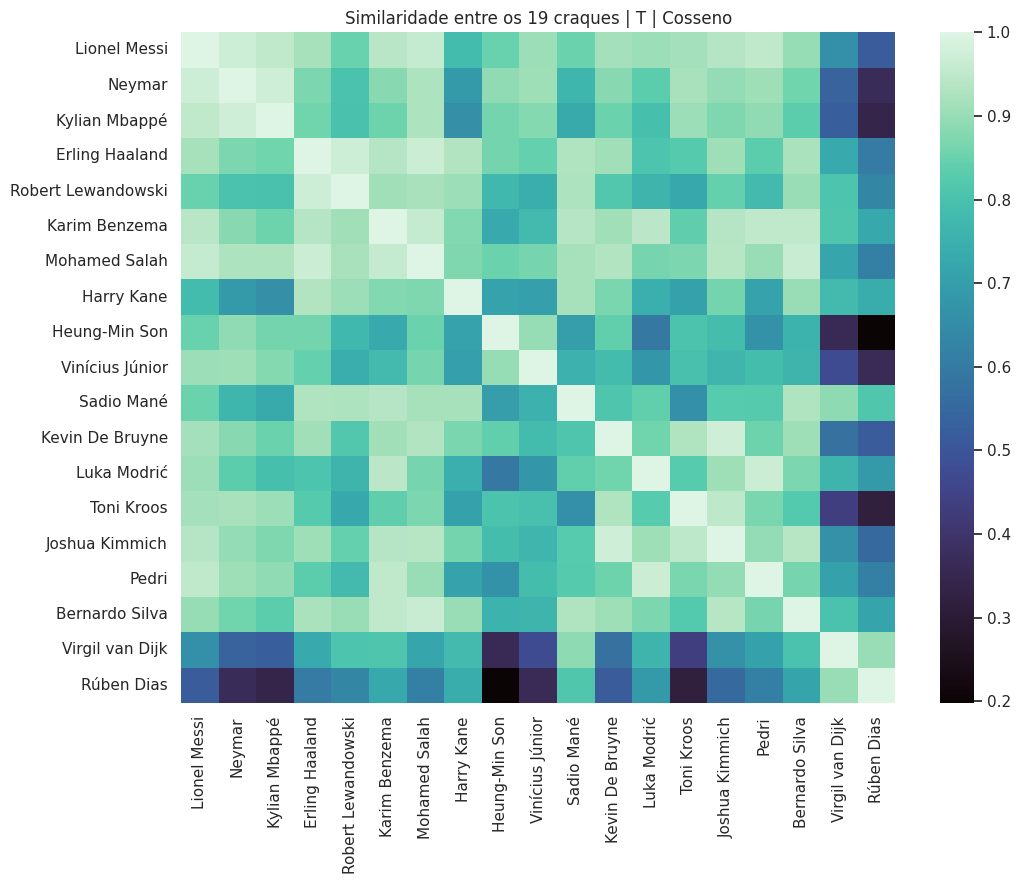

In [9]:
TWIN_ASPECT, TWIN_METRIC = "technical", "cosine"
labels = list(FAMOUS)
M, kind = pairwise(FAMOUS.values(), aspect=TWIN_ASPECT, metric=TWIN_METRIC, labels=labels)

arr = M.to_numpy().copy()
if kind == "similaridade":
    np.fill_diagonal(arr, -np.inf); pick = arr.argmax(axis=1)
else:
    np.fill_diagonal(arr, np.inf); pick = arr.argmin(axis=1)
twins = pd.DataFrame({
    "jogador": labels,
    "gêmeo famoso mais próximo": [labels[j] for j in pick],
    kind: [float(arr[i, j]) for i, j in enumerate(pick)],
}).sort_values(kind, ascending=(kind == "distância")).reset_index(drop=True)
display(twins)

plt.figure(figsize=(11, 9))
sns.heatmap(M, cmap="mako" if kind == "similaridade" else "mako_r")
plt.title(f"{kind.capitalize()} entre os {len(labels)} craques | "
          f"{ASPECT_ALIASES[ret._resolve_aspect(TWIN_ASPECT)]} | {METRIC_LABELS[TWIN_METRIC]}")
plt.tight_layout(); plt.show()

## 9. Como usar / resumo

- **Para comparar nomes:** edite os dicionários `COMPARE` / `QUERIES` / `FAMOUS` — sempre por **UID** (use `find_players("trecho")` para achar o UID certo, e `to_uid(...)` para resolver).
- **Reprodutível:** todos os scores vêm do engine canônico testado; a auditoria garante que batem com `neighbors.csv` (Jaccard@10 ≈ 1,0).
- **Econômico:** o dicionário de ~836 MB é lido uma vez, em blocos, mantendo só o necessário.
- **Honesto:** distância euclidiana é distância real; cosseno/Pearson reportam similaridade em `[-1, 1]`.
- **À prova de homônimos:** nada é resolvido por nome ambíguo — a única chave de identidade é o UID.